# Integral curves of dominant fields on $S^2$ (nonlinear non-ridge)

**Idea (2026-07-25):** instead of fixing a central tangent space, compute the dominant
direction over *changing* tangent spaces and integrate that field. The integral
curves ("trails") are candidate objects for a more principled nonlinear dimension
reduction -- the response-driven analog of *principal flows* (Panaretos, Pham & Yao,
2014), and mechanically identical to tractography: eigenvector fields are **line
fields** (sign-ambiguous per point), so tracing requires sign continuation.

Four dominant fields over the same single sample set (nonlinear non-ridge,
scanned-center cap of `projection_order.py`):

| field | definition | cost per evaluation |
|---|---|---|
| **A. re-centered intrinsic** | top tangent eigenvector of $G_x$: fixed global samples, gradients re-transported to $x$ | $N$ transports + eigensolve |
| **B. per-block dominant projection** | top eigenvector of $E_x^\top C_\iota E_x$, one fixed $C_\iota$ | eigensolve |
| **C. projected dominance** | $\pi_x\,\widehat{b}$, fixed ambient dominant $\widehat{b}$ | projection ("never extend this way") |
| **D. AMG frame field** | $w_1(p)=\mathcal{P}^{-1}_p[w_1]$, single central decomposition | transport |

At the center: A $\equiv$ D (both are the intrinsic $w_1$); B is a few degrees off
(quadratic agreement); C is $\sim 52^\circ$ off (the reordering). Away from the
center A and D part by holonomy and re-centering; the question is what their
integral curves look like -- and whether the **inactive**-field curves knit into
approximate leaves (the foliation of the paper's Frobenius remark).

In [1]:
import numpy as np
import sphere_amg as amg
from sphere_amg_demo import CMAP, GEO, get_cmap   # note: forces Agg on import
%matplotlib inline
import matplotlib.pyplot as plt

# nonlinear non-ridge over the scanned-center cap (projection_order.py config)
func = amg.make_function("nonlinear_nonridge", seed=47)
p0 = np.array([0.16, -0.76, 0.63]); p0 /= np.linalg.norm(p0)
E0 = amg.tangent_basis(p0)
RCAP = 1.45                                    # support radius (geodesic)
rng = np.random.default_rng(1)
m = 2500
rr = RCAP * np.sqrt(rng.random(m)); th = 2 * np.pi * rng.random(m)
tv = (rr * np.cos(th))[:, None] * E0[:, 0] + (rr * np.sin(th))[:, None] * E0[:, 1]
P = amg.sphere_exp_batch(p0, tv)
Gt = amg.project_tangent(func.grad(P), P)      # tangential gradients (fixed data)
C_iota = Gt.T @ Gt / m                         # one integration, fixed
b_hat = np.linalg.eigh(C_iota)[1][:, -1]       # ambient dominant
res = amg.compute_amg(func, p0, P)             # intrinsic central decomposition
w1, w2 = res.U_active, res.U_inactive
print("intrinsic lam:", np.round(res.lam, 3), "| ambient lam:", np.round(res.lam_emb, 3))
print("angle(p0, b_hat):", round(np.degrees(np.arccos(abs(p0 @ b_hat))), 1), "deg")

intrinsic lam: [17.814 12.657] | ambient lam: [15.496  9.717  5.258]
angle(p0, b_hat): 19.6 deg


In [2]:
def transport_to(P_from, p_to, V):
    '''Vectorized parallel transport on S^2: tangent vectors V[i] at P_from[i]
    carried to p_to along connecting geodesics.  Radial component rotates with
    the geodesic; the transverse (great-circle-normal) component is constant.'''
    P_from = np.atleast_2d(P_from); V = np.atleast_2d(V)
    c = P_from @ p_to
    s = np.sqrt(np.clip(1 - c**2, 0, None))
    out = V.copy()
    ok = s > 1e-12
    q, v, ci, si = P_from[ok], V[ok], c[ok, None], s[ok, None]
    e_q = (p_to[None, :] - ci * q) / si
    e_p = -si * q + ci * e_q
    a = np.sum(v * e_q, axis=1, keepdims=True)
    out[ok] = a * e_p + (v - a * e_q)
    return out

# verify against EVIE's Grassmannian transport (never trust an untested map)
_r = np.random.default_rng(0); err = 0.0
for _ in range(60):
    q = _r.standard_normal(3); q /= np.linalg.norm(q)
    p = _r.standard_normal(3); p /= np.linalg.norm(p)
    if q @ p < 0.05: continue
    v = _r.standard_normal(3); v -= (v @ q) * q
    err = max(err, np.linalg.norm(amg.parallel_transport(q, p, v)
                                  - transport_to(q[None], p, v[None])[0]))
print(f"max |vectorized - EVIE| transport error: {err:.2e}")
assert err < 1e-10

max |vectorized - EVIE| transport error: 1.20e-15


In [3]:
def field_recentered(x, which=-1):
    '''A: eigenvector of the re-centered intrinsic G_x (which=-1 dominant,
    0 inactive); fixed global samples re-transported to x.'''
    Vt = transport_to(P, x, Gt)
    Ex = amg.tangent_basis(x)
    val, vec = np.linalg.eigh(Ex.T @ (Vt.T @ Vt / m) @ Ex)
    return Ex @ vec[:, which]

def field_block(x, which=-1):
    '''B: per-block dominant projection, eigenvector of E_x^T C E_x.'''
    Ex = amg.tangent_basis(x)
    val, vec = np.linalg.eigh(Ex.T @ C_iota @ Ex)
    return Ex @ vec[:, which]

def field_projdom(x, which=-1):
    '''C: projected dominance pi_x b_hat (norm decays; vanishes at +/-b_hat).'''
    v = b_hat - (b_hat @ x) * x
    if which == 0:                       # "inactive": 90-deg rotation in T_x
        v = np.cross(x, v)
    return v

def field_transported(x, which=-1):
    '''D: AMG frame field, transported central eigenvector.'''
    w = w1 if which == -1 else w2
    return transport_to(p0[None], x, w[None])[0]

ang = lambda a, b: np.degrees(np.arccos(np.clip(
    abs(a @ b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-30), 0, 1)))
vA, vB = field_recentered(p0), field_block(p0)
vC, vD = field_projdom(p0), field_transported(p0)
print("at p0:  angle(A,D) =", round(ang(vA, vD), 3), "deg   angle(B,D) =",
      round(ang(vB, vD), 2), "deg   angle(C,D) =", round(ang(vC, vD), 2),
      "deg   ||pi0 b|| =", round(np.linalg.norm(vC), 3))

at p0:  angle(A,D) = 0.0 deg   angle(B,D) = 4.24 deg   angle(C,D) = 51.67 deg   ||pi0 b|| = 0.335


In [4]:
def trace(field, x0, which=-1, h=0.02, nmax=500, rmax=1.4, sign=1.0):
    '''Sign-continued midpoint integrator for a (line) field on the sphere.
    Stops at the cap boundary, on vanishing field, or after nmax steps.'''
    xs = [x0.copy()]
    x = x0.copy()
    v_prev = sign * field(x, which)
    for _ in range(nmax):
        v = field(x, which)
        if np.linalg.norm(v) < 1e-8: break
        v /= np.linalg.norm(v)
        if v @ v_prev < 0: v = -v
        xm = amg.sphere_exp(x, 0.5 * h * v)          # midpoint
        vm = field(xm, which)
        if np.linalg.norm(vm) < 1e-8: break
        vm /= np.linalg.norm(vm)
        vm_at_x = transport_to(xm[None], x, vm[None])[0]
        if vm_at_x @ v < 0: vm_at_x = -vm_at_x
        x_new = amg.sphere_exp(x, h * vm_at_x)
        x_new /= np.linalg.norm(x_new)
        v_prev = transport_to(x[None], x_new, v[None])[0]
        x = x_new
        xs.append(x.copy())
        if np.arccos(np.clip(x @ p0, -1, 1)) > rmax: break
    return np.array(xs)

def trace_both(field, x0, which=-1, **kw):
    fwd = trace(field, x0, which, sign=+1.0, **kw)
    bwd = trace(field, x0, which, sign=-1.0, **kw)
    return np.vstack([bwd[::-1], fwd[1:]])

# seeds: two rings + center
seeds = [p0]
for r_s, n_s in [(0.45, 6), (0.95, 8)]:
    for t_s in np.linspace(0, 2 * np.pi, n_s, endpoint=False):
        d = np.cos(t_s) * E0[:, 0] + np.sin(t_s) * E0[:, 1]
        seeds.append(amg.sphere_exp(p0, r_s * d))
print(len(seeds), "seeds")

15 seeds


In [5]:
import time
FIELDS = {r"A  re-centered intrinsic $G_x$": field_recentered,
          r"B  dominant projection $E_x^\top C_\iota E_x$": field_block,
          r"C  projected dominance $\pi_x\,\widehat{b}$": field_projdom,
          r"D  AMG frame field $\mathcal{P}^{-1}_p[w_1]$": field_transported}
curves = {}          # (label, which) -> list of ambient curves
for lab, f in FIELDS.items():
    t0 = time.time()
    for which in (-1, 0):
        curves[(lab, which)] = [trace_both(f, s, which=which) for s in seeds]
    print(f"{lab.split()[0]}: traced in {time.time()-t0:6.1f} s")

A: traced in    2.4 s


B: traced in    1.4 s


C: traced in    1.4 s


D: traced in    0.5 s


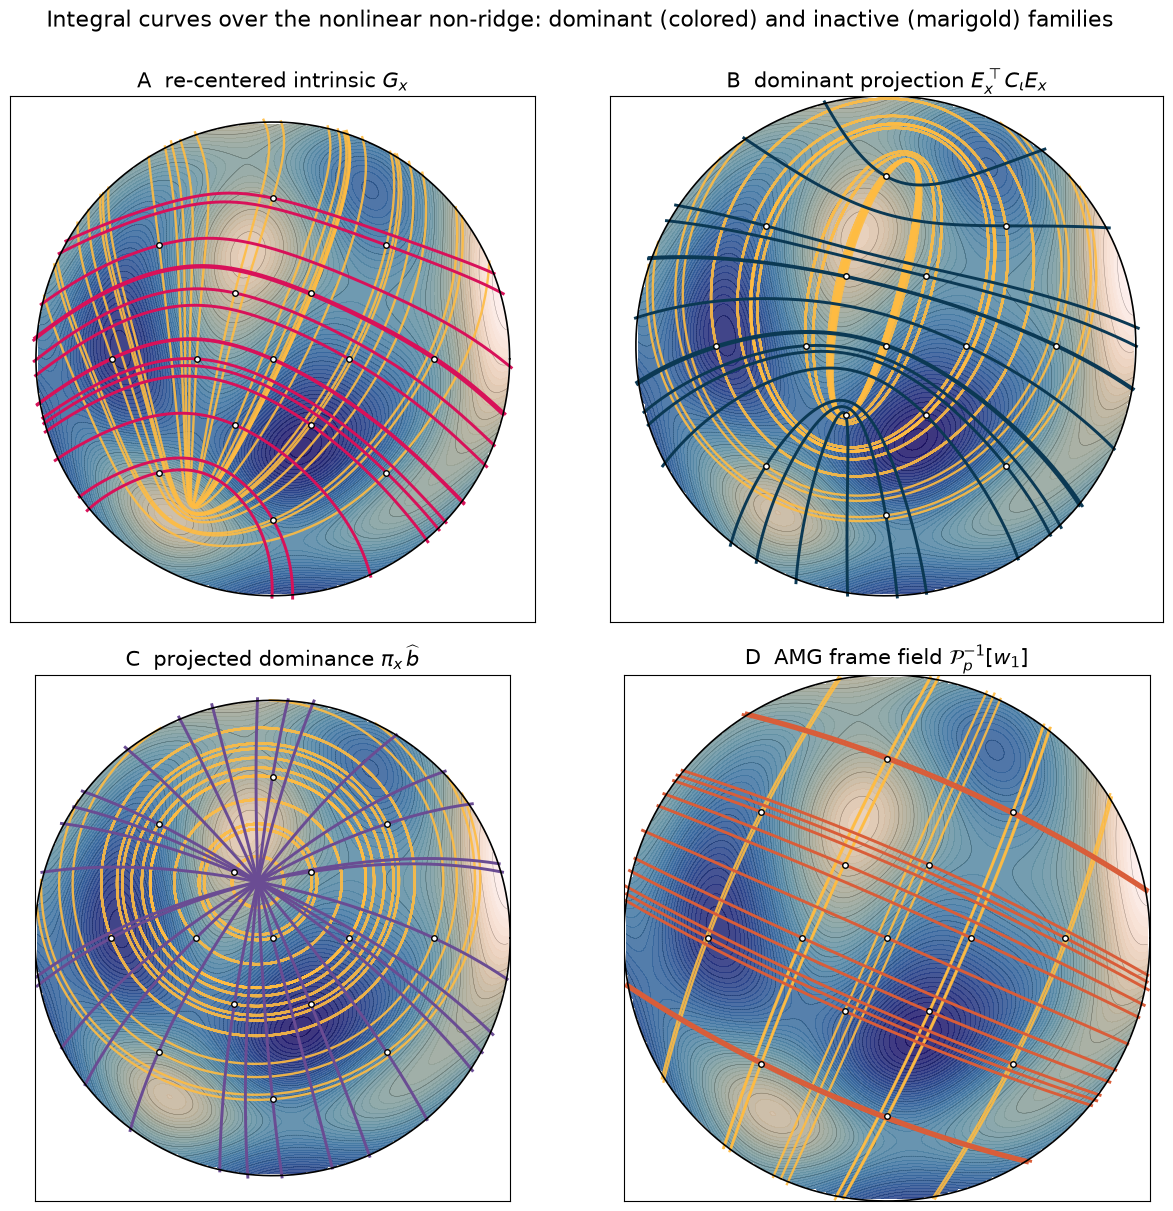

In [6]:
def to_chart(X):
    '''Log-map ambient curve points to the p0 normal-coordinate chart (E0).'''
    c = np.clip(X @ p0, -1, 1); d = np.arccos(c)
    s = np.sqrt(np.clip(1 - c**2, 0, None))
    V = np.where(s[:, None] > 1e-12,
                 (X - c[:, None] * p0) / np.where(s[:, None] > 1e-12, s[:, None], 1.0),
                 0.0)
    return d[:, None] * V @ E0

R_disp = 1.4
g = np.linspace(-R_disp, R_disp, 220)
T1, T2 = np.meshgrid(g, g)
tn = np.column_stack([T1.ravel(), T2.ravel()])
F = func.f(amg.sphere_exp_batch(p0, tn @ E0.T)).reshape(T1.shape)
F = np.where(np.hypot(T1, T2) <= R_disp, F, np.nan)

DOMC = {"A": GEO["active"], "B": "#0B3954", "C": GEO["embedding"], "D": "#D95D39"}
fig, axes = plt.subplots(2, 2, figsize=(12.6, 12.2))
for ax, (lab, f) in zip(axes.ravel(), FIELDS.items()):
    key = lab.split()[0]
    ax.contourf(T1, T2, F, 60, cmap=CMAP, alpha=0.85)
    ax.contour(T1, T2, F, 14, colors="k", linewidths=0.3, alpha=0.4)
    for cur in curves[(lab, 0)]:                       # inactive family
        t = to_chart(cur)
        ax.plot(t[:, 0], t[:, 1], color=GEO["inactive"], lw=1.7, alpha=0.9)
    for cur in curves[(lab, -1)]:                      # dominant family
        t = to_chart(cur)
        ax.plot(t[:, 0], t[:, 1], color=DOMC[key], lw=2.1)
    for s in seeds:
        t = to_chart(s[None, :])[0]
        ax.plot(*t, "o", ms=4, mfc="w", mec="k", mew=1.0, zorder=8)
    if key == "C":                                     # mark the +/- b sinks
        for bb in (b_hat, -b_hat):
            if np.arccos(np.clip(bb @ p0, -1, 1)) < R_disp:
                t = to_chart(bb[None, :])[0]
                ax.plot(*t, "x", ms=12, mew=3, color=GEO["embedding"], zorder=9)
    th_c = np.linspace(0, 2 * np.pi, 200)
    ax.plot(R_disp * np.cos(th_c), R_disp * np.sin(th_c), "k-", lw=1.2)
    ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(lab)
fig.suptitle("Integral curves over the nonlinear non-ridge: dominant (colored) and "
             "inactive (marigold) families", y=0.995)
fig.tight_layout()
fig.savefig("figs/integral_curves_chart.png", dpi=150, bbox_inches="tight")
plt.show()

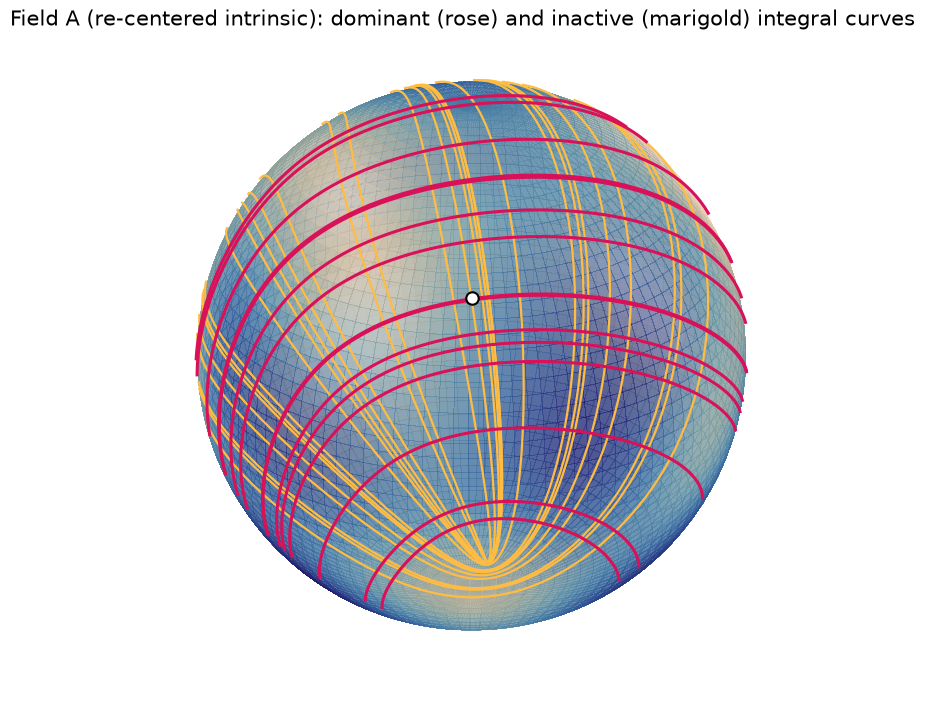

In [7]:
from sphere_amg_demo import _view_direction
elev, azim = 28, np.degrees(np.arctan2(p0[1], p0[0]))
fig = plt.figure(figsize=(9.5, 8.6))
ax = fig.add_subplot(111, projection="3d"); ax.computed_zorder = False
u = np.linspace(0, 2 * np.pi, 120); v = np.linspace(0, np.pi, 60)
XS = np.outer(np.cos(u), np.sin(v)); YS = np.outer(np.sin(u), np.sin(v))
ZS = np.outer(np.ones_like(u), np.cos(v))
FS = func.f(np.column_stack([XS.ravel(), YS.ravel(), ZS.ravel()])).reshape(XS.shape)
FSn = (FS - np.nanmin(FS)) / (np.nanmax(FS) - np.nanmin(FS))
ax.plot_surface(XS, YS, ZS, facecolors=CMAP(FSn), rstride=1, cstride=1,
                linewidth=0, antialiased=False, shade=False, alpha=0.55, zorder=0)
view = _view_direction(elev, azim)
for cur in curves[(r"A  re-centered intrinsic $G_x$", 0)]:
    near = (cur @ view) > 0.05
    ax.plot(*(cur[near] * 1.006).T, color=GEO["inactive"], lw=1.6, zorder=4)
for cur in curves[(r"A  re-centered intrinsic $G_x$", -1)]:
    near = (cur @ view) > 0.05
    ax.plot(*(cur[near] * 1.008).T, color=GEO["active"], lw=2.2, zorder=5)
ax.scatter(*(p0 * 1.02), color="w", s=80, edgecolor="k", lw=1.5, zorder=9)
ax.set_box_aspect((1, 1, 1)); ax.set_axis_off()
ax.view_init(elev=elev, azim=azim)
lim = 0.72
ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim); ax.set_zlim(-lim, lim)
ax.set_title("Field A (re-centered intrinsic): dominant (rose) and inactive "
             "(marigold) integral curves")
fig.savefig("figs/integral_curves_3d.png", dpi=150, bbox_inches="tight")
plt.show()

## Observations (2026-07-25, first run)

The four extensions produce four qualitatively different geometries:

- **C (projected dominance)** is the degenerate baseline its name deserves: its
  trails are exactly the pencil of great circles through $\pm\widehat{b}$ (the
  $\times$ marks), with concentric circles as the orthogonal family. The
  extension is determined by one ambient direction and the embedding geometry --
  blind to every other feature of the response. "Never extend by projected
  dominance," now in pictures.
- **D (AMG frame field)** is the opposite extreme: a rigid, perfectly coherent
  orthogonal grid -- the canonical extension of *one* central decomposition. Its
  curve through $p_0$ is tangent to the AMG; away from the center it is
  transport-parallel by construction and does not re-adapt to the response.
- **A (re-centered intrinsic)** is the genuinely response-adapted object. The
  dominant (rose) and inactive (marigold) families form an orthogonal
  curvilinear system that bends with the response; in the 3-D view the dominant
  family organizes into nested loops around a response-determined axis, and the
  inactive family converges at a **line-field singularity** -- a point where the
  local spectral gap closes and the dominant direction is undefined. At $p_0$,
  A coincides with the intrinsic $w_1$ exactly.
- **B (per-block dominant projection)** tracks A qualitatively over much of the
  cap at a fraction of the cost (one $2\times2$ eigensolve per point; its only
  $x$-dependence is the compression $E_x$, the response enters through the one
  fixed $C_\iota$). It develops additional degenerate points (the classic
  index-$\pm 1/2$ line-field patterns) where *its* local gap closes -- precisely
  where the $\mathcal{O}(R^2/\eta)$ Davis--Kahan control fails.

**Not gradient flow.** The dominant field is the top eigenvector of an
*integrated second moment* -- sign-free and variance-driven -- so its trails
cross level sets at varying angles and need not terminate at critical points of
$f$. The marigold loops are not level curves (compare the background contours);
they are integrated inactive directions.

**Is this a more principled nonlinear dimension reduction?** Promising, with
three honest caveats:

1. *Centering/measure choice.* A re-centers the same fixed global samples; a
   fully intrinsic definition would re-wrap $\mu$ at each center or localize
   with a kernel -- the recipe of **principal flows** (Panaretos, Pham & Yao,
   2014), of which this is the response-driven (gradient second-moment) analog.
2. *Singularities are structural.* Eigenvector line fields generically carry
   index-$\pm1/2$ singularities where the gap closes, and the topology of the
   cap can force them (Poincare--Hopf). A flow-based reduction must treat them
   as features (response umbilics), not failures.
3. *Identifiability.* Remark rem:dichotomy warns that unconstrained curve
   fitting degenerates. Here regularization enters through integration (the
   field is not a greedy pointwise direction), but no complexity bound or
   variational characterization is established yet -- principal flows have one;
   a response-driven analog is open and would give existence/uniqueness through
   the singular set.

**Next:** variational formulation; re-wrapped vs kernel-localized measures
(ablation); color trails by the local gap $\eta(x)$; repeat on the preferential
quadratic (should reduce to near-geodesics); connect the inactive family to the
foliation remark (leaves as inactive flows).